# Showcase — Hurricane Ian's life cycle (Tropycal)

Hurricane **Ian** (September 2022) peaked as a **Category 5** with 160 mph (140 kt) sustained winds and a 936 hPa central pressure, and underwent **rapid intensification** — winds jumped from 60 to 125 mph in under a day — before devastating southwest Florida. Best-track data (HURDAT2) records its position and intensity every six hours; earthlens returns it as a `GeoDataFrame` of fixes.

## What this notebook does

1. **Query Tropycal** for Ian's six-hourly best track.
2. **Map** the track coloured by wind speed.
3. **Wind & pressure** timelines together.
4. **Rapid intensification**: find and highlight the ≥30 kt / 24 h jump.
5. **Pressure–wind** relationship.
6. **Accumulated Cyclone Energy (ACE)** — an integrated measure of the storm's power.

> Needs the `[tropycal]` extra; otherwise the cells skip gracefully.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loguru import logger

from earthlens import EarthLens

logger.disable("earthlens")
logger.disable("pyramids")

# --- Query Tropycal for north-Atlantic best track, keep only Ian ---
fixes = None
try:
    fixes = EarthLens(
        data_source="tropycal",
        variables=["north_atlantic"],
        start="2022-09-23",
        end="2022-10-01",
        aoi=[-90.0, 12.0, -70.0, 34.0],
        source="hurdat",
    ).load(progress_bar=False)
    fixes = (
        fixes[fixes["name"].str.upper() == "IAN"]
        .sort_values("time")
        .reset_index(drop=True)
    )
    fixes["time"] = pd.to_datetime(fixes["time"])
    print(
        f"{len(fixes)} six-hourly fixes; peak {fixes.vmax_kt.max():.0f} kt, "
        f"min pressure {fixes.mslp_hpa.min():.0f} hPa"
    )
except Exception as exc:  # noqa: BLE001
    print("skipped live query:", exc)

34 six-hourly fixes; peak 140 kt, min pressure 937 hPa


## Track coloured by maximum sustained wind

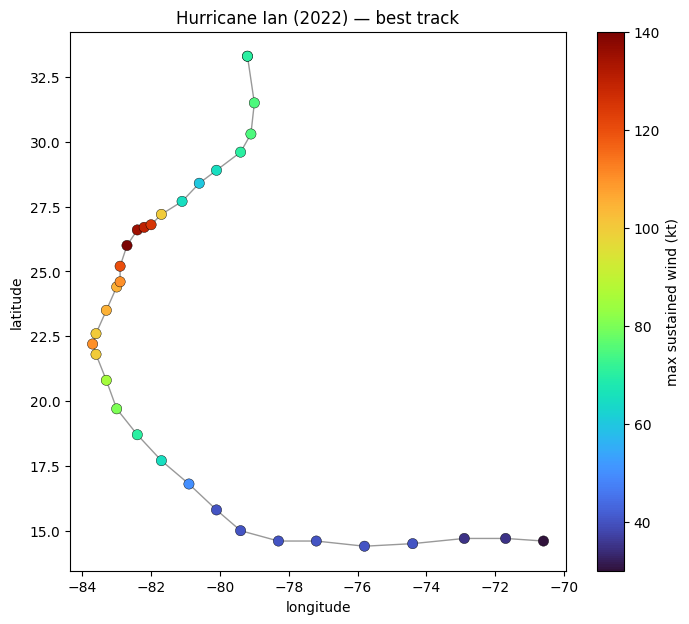

In [2]:
# Path with each six-hourly fix coloured by intensity.
if fixes is not None and len(fixes):
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fixes.lon, fixes.lat, "-", color="0.6", lw=1, zorder=1)
    sc = ax.scatter(
        fixes.lon,
        fixes.lat,
        c=fixes.vmax_kt,
        cmap="turbo",
        s=55,
        edgecolor="k",
        linewidth=0.3,
        zorder=2,
    )
    ax.set(
        xlabel="longitude", ylabel="latitude", title="Hurricane Ian (2022) — best track"
    )
    fig.colorbar(sc, ax=ax, label="max sustained wind (kt)")
    plt.show()

## Wind and pressure timelines

Wind and central pressure mirror each other — as the storm intensifies, pressure drops. Saffir–Simpson category thresholds are drawn for reference.

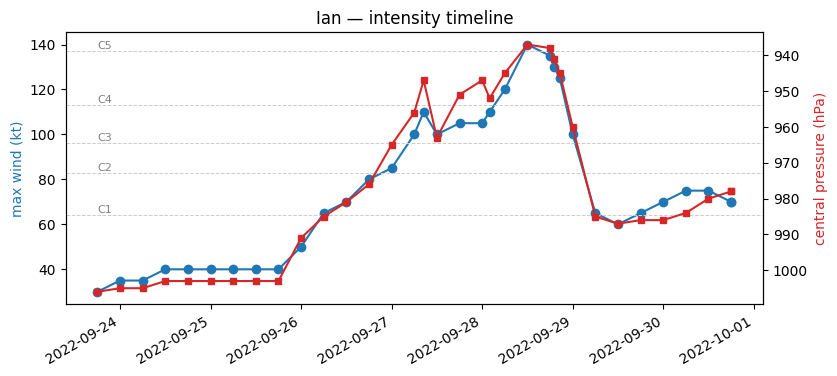

In [3]:
# Wind (left axis) and central pressure (right axis) over time.
if fixes is not None and len(fixes):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(fixes.time, fixes.vmax_kt, "-o", color="tab:blue", label="wind (kt)")
    for kt, lab in [(64, "C1"), (83, "C2"), (96, "C3"), (113, "C4"), (137, "C5")]:
        ax.axhline(kt, color="0.8", ls="--", lw=0.7)
        ax.text(fixes.time.iloc[0], kt + 1, lab, fontsize=8, color="0.5")
    ax.set_ylabel("max wind (kt)", color="tab:blue")
    ax2 = ax.twinx()
    ax2.plot(fixes.time, fixes.mslp_hpa, "-s", color="tab:red", ms=4)
    ax2.set_ylabel("central pressure (hPa)", color="tab:red")
    ax2.invert_yaxis()
    ax.set_title("Ian — intensity timeline")
    fig.autofmt_xdate()
    plt.show()

## Rapid intensification

The NHC defines **rapid intensification (RI)** as a ≥30 kt increase in maximum wind within 24 hours. We compute the 24 h (4-fix) wind change and flag any window that crosses that threshold.

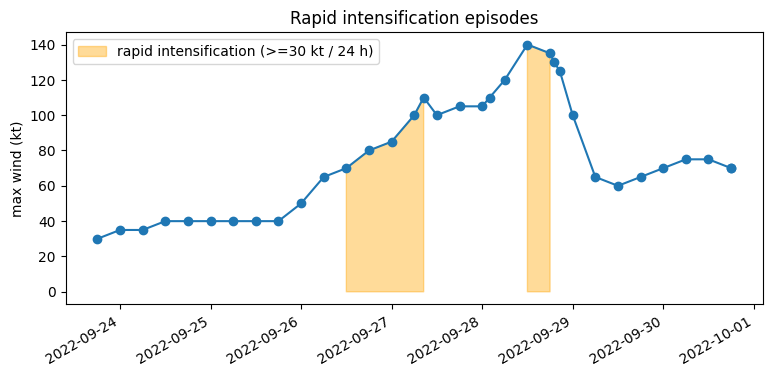

peak 24 h intensification: +40 kt


In [4]:
# 24-hour wind change (4 six-hourly steps); shade RI windows (>=30 kt / 24 h).
if fixes is not None and len(fixes):
    d24 = fixes.vmax_kt.diff(4)  # change over 4 x 6 h = 24 h
    ri = d24 >= 30
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(fixes.time, fixes.vmax_kt, "-o", color="tab:blue")
    ax.fill_between(
        fixes.time,
        0,
        fixes.vmax_kt,
        where=ri.fillna(False),
        color="orange",
        alpha=0.4,
        label="rapid intensification (>=30 kt / 24 h)",
    )
    ax.set(ylabel="max wind (kt)", title="Rapid intensification episodes")
    ax.legend()
    fig.autofmt_xdate()
    plt.show()
    print(f"peak 24 h intensification: +{d24.max():.0f} kt")

## Pressure–wind relationship

A tighter, more familiar view: every tropical cyclone roughly follows a wind–pressure curve.

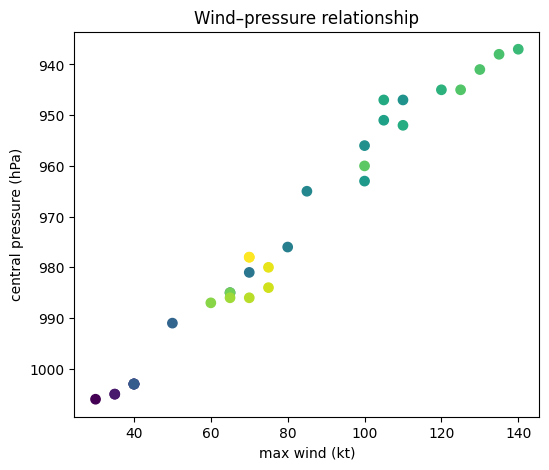

In [5]:
if fixes is not None and len(fixes):
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(
        fixes.vmax_kt,
        fixes.mslp_hpa,
        c=fixes.time.astype("int64"),
        cmap="viridis",
        s=45,
    )
    ax.set(
        xlabel="max wind (kt)",
        ylabel="central pressure (hPa)",
        title="Wind–pressure relationship",
    )
    ax.invert_yaxis()
    plt.show()

## Accumulated Cyclone Energy (ACE)

ACE integrates the square of the maximum wind over the storm's life (only while ≥34 kt), in units of 10⁴ kt². It is the standard single number for a storm's overall power.

In [6]:
# ACE = sum of vmax^2 / 1e4 over six-hourly fixes with vmax >= 34 kt.
if fixes is not None and len(fixes):
    ace = ((fixes.vmax_kt[fixes.vmax_kt >= 34]) ** 2).sum() / 1e4
    print(
        f"Hurricane Ian ACE = {ace:.1f} x 10^4 kt^2 "
        f"(a single major hurricane; the whole 2022 Atlantic season was ~95)"
    )

Hurricane Ian ACE = 23.6 x 10^4 kt^2 (a single major hurricane; the whole 2022 Atlantic season was ~95)


## Recap

The earthlens **Tropycal** backend turns the official best track into a `GeoDataFrame`, from which the whole life cycle follows: the track, the wind/pressure mirror, the rapid-intensification burst, the wind–pressure curve, and a single ACE figure.

## Try it yourself

- Change the storm name/dates, or the basin (`variables=['east_pacific']`).
- Compare two storms' ACE or RI on the same axes.
- See the [Tropycal backend reference](../../reference/tropycal/introduction.md).